# Reaction-Diffusion Model

Bin Wang (wbwenwu@gmail.com|wangb@ornl.gov)

2025/01

---

Here, we simulate a system proposed by Alan Turing as a model of animal coat pattern formation. Two chemical substances influencing skin pigmentation interact according to a reaction-diffusion model. This system is responsible for the formation of patterns that are reminiscent of the pelage of zebras, jaguars, and giraffes.

We will simulate this system with the **finite difference method**. This method consists of discretizing time and space and replacing the derivatives with their discrete equivalents.


**Reference**:

https://ipython-books.github.io/124-simulating-a-partial-differential-equation-reaction-diffusion-systems-and-turing-patterns/

https://en.wikipedia.org/wiki/Reaction%E2%80%93diffusion_system

In [3]:
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

In [4]:
a = 2.8e-4
b = 5e-3
tau = .1
k = -.005

In [5]:
size = 100  # size of the 2D grid
dx = 2. / size  # space step

T = 9.0  # total time
dt = .001  # time step
n = int(T / dt)  # number of iterations

In [6]:
U = np.random.rand(size, size)
V = np.random.rand(size, size)

Now, we define a function that computes the discrete Laplace operator of a 2D variable on the grid, using [a five-point stencil finite difference method](https://www.perplexity.ai/search/a-five-point-stencil-finite-di-78RrwauiQ8i.0N3R_uofEA). This operator is defined by:

$Δu(x,y)≃ (u(x+h,y)+u(x−h,y)+u(x,y+h)+u(x,y−h)−4u(x,y))/dx2$

We can compute the values of this operator on the grid using vectorized matrix operations. Because of side effects on the edges of the matrix, we need to remove the borders of the grid in the computation:

In [7]:
def laplacian(Z):
    Ztop    = Z[0:-2, 1:-1]
    Zleft   = Z[1:-1, 0:-2]
    Zbottom = Z[2:, 1:-1]
    Zright  = Z[1:-1, 2:]
    Zcenter = Z[1:-1, 1:-1]
    return (Ztop + Zleft + Zbottom + Zright - 4 * Zcenter) / dx**2

In [8]:
def show_patterns(U, ax=None):
    ax.imshow(U, cmap=plt.cm.copper,
              interpolation='bilinear',
              extent=[-1, 1, -1, 1])
    ax.set_axis_off()

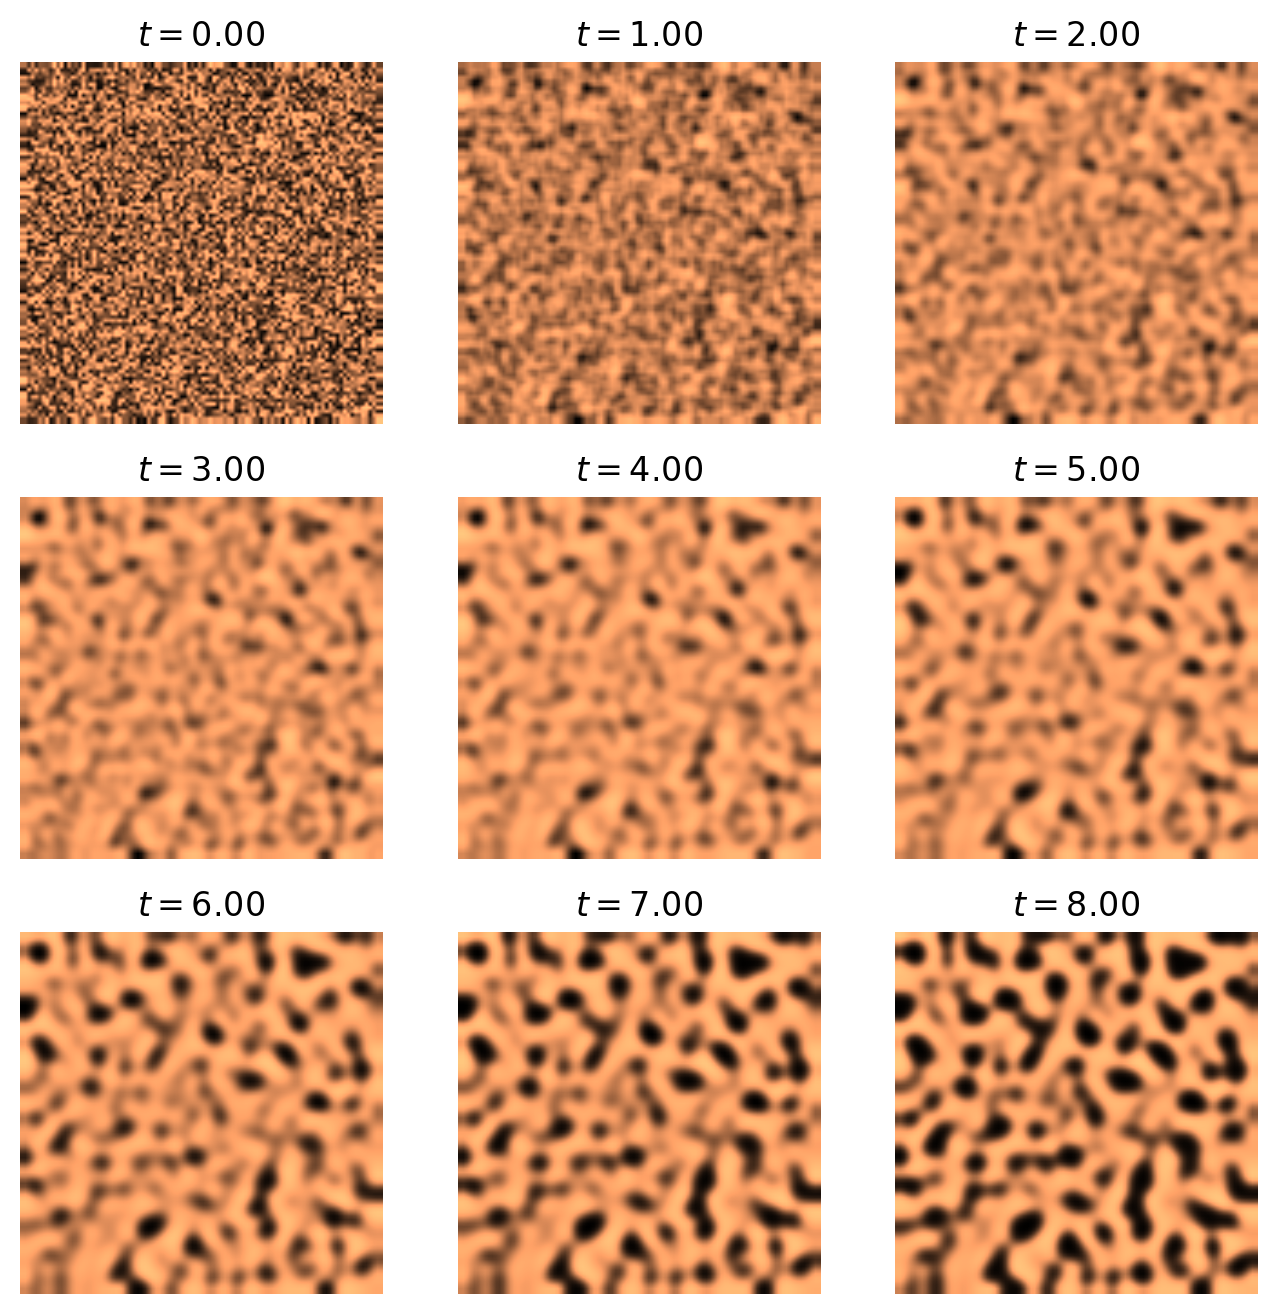

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
step_plot = n // 9
# We simulate the PDE with the finite difference
# method.
for i in range(n):
    # We compute the Laplacian of u and v.
    deltaU = laplacian(U)
    deltaV = laplacian(V)
    # We take the values of u and v inside the grid.
    Uc = U[1:-1, 1:-1]
    Vc = V[1:-1, 1:-1]
    # We update the variables.
    U[1:-1, 1:-1], V[1:-1, 1:-1] = \
        Uc + dt * (a * deltaU + Uc - Uc**3 - Vc + k),\
        Vc + dt * (b * deltaV + Uc - Vc) / tau
    # Neumann conditions: derivatives at the edges
    # are null.
    for Z in (U, V):
        Z[0, :] = Z[1, :]
        Z[-1, :] = Z[-2, :]
        Z[:, 0] = Z[:, 1]
        Z[:, -1] = Z[:, -2]

    # We plot the state of the system at
    # 9 different times.
    if i % step_plot == 0 and i < 9 * step_plot:
        ax = axes.flat[i // step_plot]
        show_patterns(U, ax=ax)
        ax.set_title(f'$t={i * dt:.2f}$')

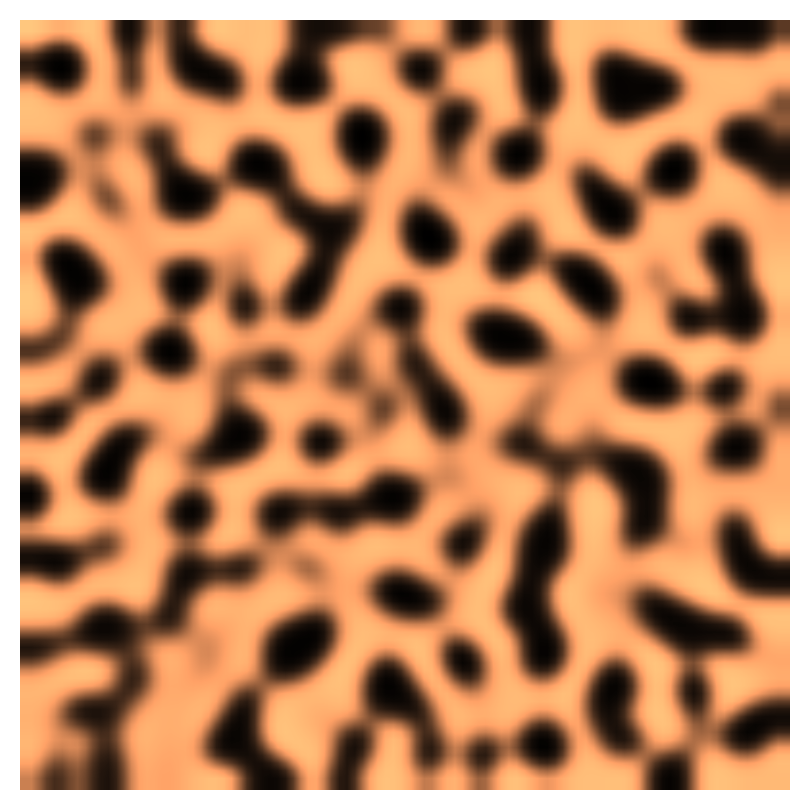

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
show_patterns(U, ax=ax)

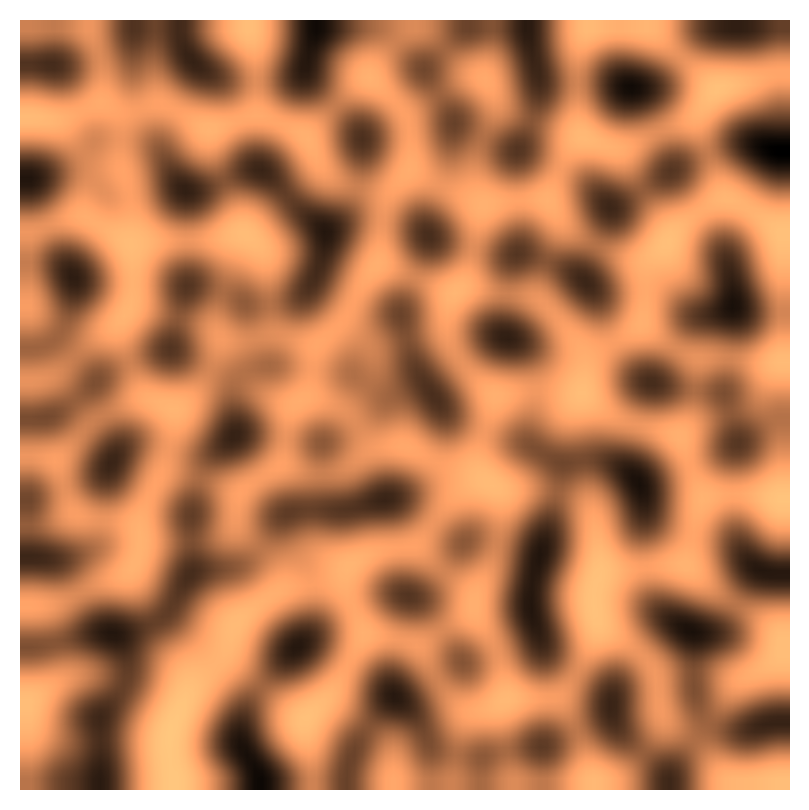

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
show_patterns(V, ax=ax)